# 📊 Proyek 3: K-Means Clustering dengan Cosine Similarity / Cosine Distance

**Author:** Senior Data Scientist & Machine Learning Engineer Expert  
**Dataset:** `dataset_properti.csv`  
**Metrik Jarak:** Cosine Distance ($1 - \text{Cosine Similarity}$)  
**Fungsi Objektif:** Cosine Dispersion / Angular Inertia  
**Output Target:** `outputKmeans_Properti/elbow_cosine.png`, `outputKmeans_Properti/cluster_cosine.png`, `outputKmeans_Properti/evaluasi_kmeans_cosine.xlsx`

---

## 📌 Ringkasan Proyek
Proyek ini mengimplementasikan **Spherical K-Means Clustering** berbasis **Cosine Similarity / Cosine Distance**. Berbeda dari metrik berbasis magnitudo, Cosine Distance berfokus pada orientasi sudut deviasi antar vektor fitur, mengabaikan panjang vektor absolutnya. Seluruh data dan titik pusat diproyeksikan pada permukaan bola satuan hiper-dimensi (*unit hypersphere*, $\|x\|_2 = 1$). Sangat unggul untuk data berdimensi tinggi, data proporsi/rasio, atau tren temporal.

## 📐 1. Formulasi Matematis Cosine Distance & Fungsi Objektif

### 1.1. Cosine Distance
Jarak deviasi sudut orientasi antara dua vektor $x, y \in \mathbb{R}^n$:
$$d_{\text{Cosine}}(x, y) = 1 - \cos(x, y) = 1 - \frac{\sum_{i=1}^{n} x_i y_i}{\sqrt{\sum_{i=1}^{n} x_i^2} \sqrt{\sum_{i=1}^{n} y_i^2}} = 1 - \frac{x \cdot y}{\|x\|_2 \|y\|_2}$$

### 1.2. Fungsi Objektif (Cosine Inertia)
Fungsi dispersi angular yang diminimalkan:
$$J_{\text{Cosine}} = \sum_{k=1}^{K} \sum_{x \in S_k} d_{\text{Cosine}}(x, \mu_k) = \sum_{k=1}^{K} \sum_{x \in S_k} \left(1 - \frac{x \cdot \mu_k}{\|x\|_2 \|\mu_k\|_2}\right)$$

> **Pembaruan Titik Pusat (Spherical K-Means):**  
> Pada ruang ter-normalisasi satuan ($\|x\|_2 = 1$), titik pusat optimal pada permukaan bola diperoleh dengan menghitung rata-rata vektor lalu menormalkannya kembali:
> $$\mu_k^* = \frac{\sum_{x \in S_k} x}{\left\|\sum_{x \in S_k} x\right\|_2}$$

In [1]:
# =======================================================================
# 1. SETUP LINGKUNGAN & IMPORT PUSTAKA
# =======================================================================
import os
import sys
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

OUTPUT_DIR = "outputKmeans_Properti"
os.makedirs(OUTPUT_DIR, exist_ok=True)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("[INFO] Pustaka berhasil dimuat.")
print(f"[INFO] Folder output: '{OUTPUT_DIR}' | Random state: {RANDOM_STATE}")

[INFO] Pustaka berhasil dimuat.
[INFO] Folder output: 'outputKmeans_Properti' | Random state: 42


In [2]:
# =======================================================================
# 2. PEMUATAN DATASET & PRA-PEMROSESAN (L2 NORMALIZATION)
# =======================================================================
def load_and_preprocess_data():
    candidate_paths = [
        os.path.join("..", "dataset", "dataset_properti.csv"),
        "dataset_properti.csv",
        os.path.join("dataset", "dataset_properti.csv")
    ]

    valid_path = None
    for p in candidate_paths:
        if os.path.exists(p):
            valid_path = p
            break

    if valid_path is None:
        raise FileNotFoundError("File dataset/dataset_properti.csv tidak ditemukan.")

    print(f"[DATA] Membaca dataset dari: '{valid_path}'")
    df_raw = pd.read_csv(valid_path)
    print(f"[DATA] Dimensi awal dataset: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")

    # --- Cleaning dataset properti ---
    # 1. Hapus kolom id_properti
    df_clean = df_raw.drop(columns=['id_properti'])

    # 2. Bersihkan kolom luas_m2 dari satuan "m2"
    df_clean['luas_m2'] = df_clean['luas_m2'].astype(str).str.replace(' m2', '', regex=False)
    df_clean['luas_m2'] = pd.to_numeric(df_clean['luas_m2'], errors='coerce')

    # 3. Standarisasi lokasi
    df_clean['lokasi'] = df_clean['lokasi'].str.strip().str.title()

    # 4. Hapus duplikat
    df_clean = df_clean.drop_duplicates()

    # 5. Imputasi missing values dengan median (SimpleImputer)
    num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    imputer = SimpleImputer(strategy='median')
    df_clean[num_cols] = imputer.fit_transform(df_clean[num_cols])

    # 6. Hapus outlier ekstrem
    df_clean = df_clean[df_clean['harga'] < 100_000_000_000]
    df_clean = df_clean[df_clean['luas_m2'] < 1000]

    # 7. Pilih fitur numerik untuk clustering
    feature_cols = ['luas_m2', 'jumlah_kamar', 'jumlah_kamar_mandi', 'usia_bangunan', 'harga']
    df_features = df_clean[feature_cols].astype(float).reset_index(drop=True)

    # Standarisasi awal lalu L2 Normalization (proyeksi ke unit hypersphere)
    X_std = StandardScaler().fit_transform(df_features.values)
    X_scaled = Normalizer(norm='l2').fit_transform(X_std)
    return df_clean, df_features, X_scaled

df_clean, df_features, X_scaled = load_and_preprocess_data()
X_norm = X_scaled  # nama variabel sama seperti pada notebook contoh
print(f"[DATA] Sampel norma L2 vektor pertama: {np.linalg.norm(X_norm[:3], axis=1)}")
print(f"[DATA] Fitur siap dimodelkan ({X_scaled.shape[1]} dimensi): {list(df_features.columns)}")
df_features.head()

[DATA] Membaca dataset dari: '..\dataset\dataset_properti.csv'
[DATA] Dimensi awal dataset: 1530 baris x 8 kolom
[DATA] Sampel norma L2 vektor pertama: [1. 1. 1.]
[DATA] Fitur siap dimodelkan (5 dimensi): ['luas_m2', 'jumlah_kamar', 'jumlah_kamar_mandi', 'usia_bangunan', 'harga']


,luas_m2,jumlah_kamar,jumlah_kamar_mandi,usia_bangunan,harga
0,30.0,3.0,3.0,33.0,2.037543e+08
1,122.0,5.0,4.0,19.0,1.058032e+09
2,142.8,1.0,1.0,9.0,1.335793e+09
3,152.6,4.0,3.0,6.0,1.613771e+09
4,61.2,1.0,1.0,9.0,5.221562e+08


## 📈 2. Penentuan Jumlah Klaster Optimal (Elbow Method Cosine)

Metode Elbow Cosine mengukur nilai **Cosine Inertia** terhadap variasi nilai $k \in [1, 10]$:
$$J_{\text{Cosine}}(k) = \sum_{j=1}^{k} \sum_{x \in S_j} (1 - \cos(x, \mu_j))$$

Titik pembelokan tajam (*elbow point*) mengindikasikan partisi sudut optimal antarklaster.

In [3]:
# =======================================================================
# 3. KELAS K-MEANS COSINE (SPHERICAL K-MEANS)
# =======================================================================
class KMeansCosine:
    """
    Algoritma Spherical K-Means berbasis Cosine Distance.
    Centroid diperbarui sebagai vektor rata-rata ter-normalisasi pada unit hypersphere.
    """
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = 0.0  # Cosine Inertia
        self.n_iter_ = 0
        self.execution_time_ = 0.0

    def _compute_distance(self, X, centroids):
        # Cosine distance: 1 - (X . centroids) / (||X|| ||centroids||)
        return pairwise_distances(X, centroids, metric='cosine')

    def _init_centroids(self, X):
        rng = np.random.RandomState(self.random_state)
        n_samples, _ = X.shape
        first_idx = rng.randint(n_samples)
        centroids = [X[first_idx]]

        for _ in range(1, self.n_clusters):
            cur_c = np.array(centroids)
            dists = self._compute_distance(X, cur_c)
            min_dists = np.min(dists, axis=1)
            sq_dists = min_dists ** 2
            sum_sq = np.sum(sq_dists)
            probs = np.ones(n_samples) / n_samples if sum_sq == 0 else sq_dists / sum_sq
            next_idx = rng.choice(n_samples, p=probs)
            centroids.append(X[next_idx])
            
        centroids = np.array(centroids)
        # Normalisasi L2 ke unit hypersphere
        norms = np.linalg.norm(centroids, axis=1, keepdims=True)
        norms[norms == 0] = 1e-10
        return centroids / norms

    def fit(self, X):
        start_time = time.perf_counter()
        
        # Pastikan input adalah unit vector
        norms = np.linalg.norm(X, axis=1, keepdims=True)
        norms[norms == 0] = 1e-10
        X_calc = X / norms

        self.centroids = self._init_centroids(X_calc)

        for it in range(self.max_iter):
            self.n_iter_ = it + 1
            # Assignment Step: Menggunakan Cosine Distance
            dists = self._compute_distance(X_calc, self.centroids)
            labels = np.argmin(dists, axis=1)

            # Update Step: Normalisasi rata-rata vektor ke permukaan bola satuan
            new_centroids = np.zeros_like(self.centroids)
            rng = np.random.RandomState(self.random_state)
            for k in range(self.n_clusters):
                cluster_pts = X_calc[labels == k]
                if len(cluster_pts) == 0:
                    new_centroids[k] = X_calc[rng.randint(len(X_calc))]
                else:
                    mean_vec = np.mean(cluster_pts, axis=0)
                    norm = np.linalg.norm(mean_vec)
                    new_centroids[k] = mean_vec / (norm if norm > 0 else 1.0)

            shift = np.linalg.norm(new_centroids - self.centroids)
            self.centroids = new_centroids
            self.labels_ = labels

            if shift < self.tol:
                break

        # Komputasi Nilai Fungsi Objektif Cosine: J = sum_{k=1}^K sum_{x in S_k} d_Cosine(x, mu_k)
        final_dists = self._compute_distance(X_calc, self.centroids)
        assigned_dists = final_dists[np.arange(len(X_calc)), self.labels_]
        self.inertia_ = float(np.sum(assigned_dists))
        self.execution_time_ = float(time.perf_counter() - start_time)
        return self

print("[INFO] Kelas KMeansCosine berhasil diinisialisasi.")

[INFO] Kelas KMeansCosine berhasil diinisialisasi.


[ELBOW] Jumlah Klaster Optimal Terdeteksi: k = 3


[SIMPAN] Grafik Elbow disimpan ke: 'outputKmeans_Properti\elbow_cosine.png'


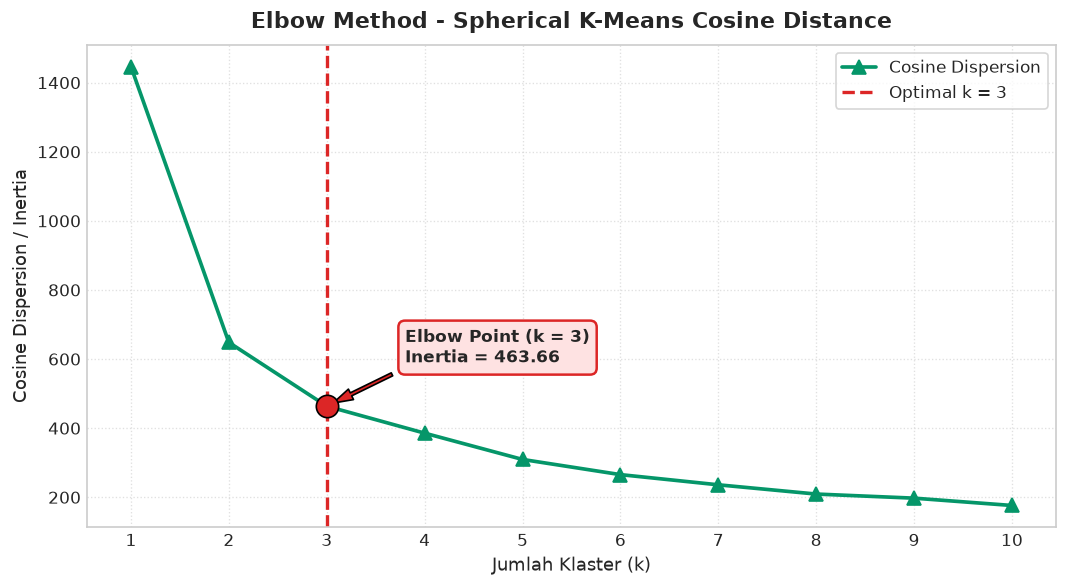

In [4]:
# =======================================================================
# 4. EKSEKUSI ELBOW METHOD COSINE ($k=1..10$)
# =======================================================================
k_range = list(range(1, 11))
inertia_cosine = []

for k in k_range:
    km = KMeansCosine(n_clusters=k, max_iter=200, random_state=RANDOM_STATE)
    km.fit(X_norm)
    inertia_cosine.append(km.inertia_)

def find_elbow_point(k_vals, inertias):
    p1 = np.array([k_vals[0], inertias[0]])
    p2 = np.array([k_vals[-1], inertias[-1]])
    line_vec = p2 - p1
    line_unit = line_vec / np.linalg.norm(line_vec)
    dists = [np.linalg.norm((np.array([k, s]) - p1) - np.dot(np.array([k, s]) - p1, line_unit) * line_unit) for k, s in zip(k_vals, inertias)]
    return k_vals[np.argmax(dists)]

optimal_k = find_elbow_point(k_range, inertia_cosine)
print(f"[ELBOW] Jumlah Klaster Optimal Terdeteksi: k = {optimal_k}")

# Plotting Elbow Curve
plt.figure(figsize=(9, 5))
plt.plot(k_range, inertia_cosine, marker='^', markersize=8, linewidth=2.2, color='#059669', label='Cosine Dispersion')
plt.axvline(x=optimal_k, color='#DC2626', linestyle='--', linewidth=2, label=f'Optimal k = {optimal_k}')
plt.scatter([optimal_k], [inertia_cosine[optimal_k - 1]], color='#DC2626', s=180, zorder=5, edgecolor='black')

plt.title('Elbow Method - Spherical K-Means Cosine Distance', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Jumlah Klaster (k)', fontsize=11)
plt.ylabel('Cosine Dispersion / Inertia', fontsize=11)
plt.xticks(k_range)
plt.annotate(
    f'Elbow Point (k = {optimal_k})\nInertia = {inertia_cosine[optimal_k - 1]:,.2f}',
    xy=(optimal_k, inertia_cosine[optimal_k - 1]),
    xytext=(optimal_k + 0.8, inertia_cosine[optimal_k - 1] + (max(inertia_cosine)-min(inertia_cosine))*0.1),
    arrowprops=dict(facecolor='#DC2626', shrink=0.08, width=2, headwidth=7),
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#FEE2E2", edgecolor="#DC2626", lw=1.5),
    fontweight='bold', fontsize=10
)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()

elbow_path = os.path.join(OUTPUT_DIR, "elbow_cosine.png")
plt.savefig(elbow_path, dpi=300)
print(f"[SIMPAN] Grafik Elbow disimpan ke: '{elbow_path}'")
plt.show()

In [5]:
# =======================================================================
# 5. EKSEKUSI CLUSTERING, METRIK EVALUASI, & EKSPOR EXCEL
# =======================================================================
model_cosine = KMeansCosine(n_clusters=optimal_k, max_iter=300, tol=1e-4, random_state=RANDOM_STATE)
model_cosine.fit(X_norm)

# Metrik Evaluasi (Silhouette dihitung dengan metric='cosine')
sil_score = float(silhouette_score(X_norm, model_cosine.labels_, metric='cosine'))
db_score = float(davies_bouldin_score(X_norm, model_cosine.labels_))
ch_score = float(calinski_harabasz_score(X_norm, model_cosine.labels_))

eval_df = pd.DataFrame([{
    'Distance Metric': 'Cosine Distance (Spherical)',
    'Optimal k': optimal_k,
    'Silhouette Score (↑)': round(sil_score, 4),
    'Davies–Bouldin Index (↓)': round(db_score, 4),
    'Calinski–Harabasz Index (↑)': round(ch_score, 2),
    'Execution Time (s) (↓)': round(model_cosine.execution_time_, 5),
    'Iterations (↓)': model_cosine.n_iter_,
    'Objective Value (Inertia) (↓)': round(model_cosine.inertia_, 2)
}])

print("\n" + "="*80)
print("TABEL EVALUASI K-MEANS COSINE")
print("="*80)
print(eval_df.to_string(index=False))
print("="*80)

# Simpan ke Berkas Excel (.xlsx) dengan 2 Sheet
excel_path = os.path.join(OUTPUT_DIR, "evaluasi_kmeans_cosine.xlsx")

df_clustered = df_clean.copy()
df_clustered['Cluster_Cosine'] = model_cosine.labels_

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    eval_df.to_excel(writer, sheet_name='Ringkasan_Evaluasi', index=False)
    df_clustered.to_excel(writer, sheet_name='Data_Terklaster', index=False)

print(f"[SIMPAN] Hasil evaluasi dan data terklaster disimpan ke: '{excel_path}'")


TABEL EVALUASI K-MEANS COSINE
            Distance Metric  Optimal k  Silhouette Score (↑)  Davies–Bouldin Index (↓)  Calinski–Harabasz Index (↑)  Execution Time (s) (↓)  Iterations (↓)  Objective Value (Inertia) (↓)
Cosine Distance (Spherical)          3                0.4489                    1.2135                       680.65                 0.02904              20                         463.66


[SIMPAN] Hasil evaluasi dan data terklaster disimpan ke: 'outputKmeans_Properti\evaluasi_kmeans_cosine.xlsx'


[SIMPAN] Grafik pemetaan klaster disimpan ke: 'outputKmeans_Properti\cluster_cosine.png'


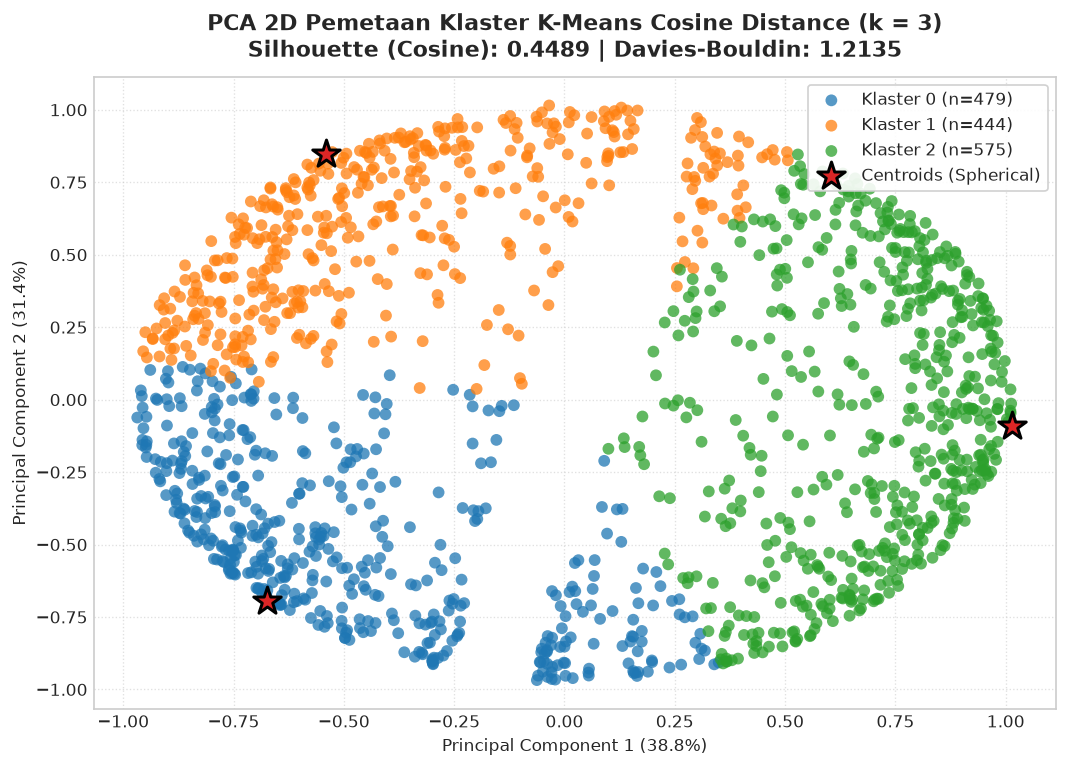

In [6]:
# =======================================================================
# 6. VISUALISASI PCA 2D PEMETAAN KLASTER & CENTROIDS
# =======================================================================
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_norm)
centroids_pca = pca.transform(model_cosine.centroids)

plt.figure(figsize=(9, 6.5))
palette = sns.color_palette("tab10", optimal_k)

for k in range(optimal_k):
    mask = (model_cosine.labels_ == k)
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        color=palette[k],
        label=f'Klaster {k} (n={np.sum(mask)})',
        alpha=0.75,
        s=50,
        edgecolors='none'
    )

plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    marker='*',
    s=300,
    c='#DC2626',
    edgecolor='black',
    linewidth=1.8,
    label='Centroids (Spherical)',
    zorder=10
)

plt.title(f'PCA 2D Pemetaan Klaster K-Means Cosine Distance (k = {optimal_k})\n'
          f'Silhouette (Cosine): {sil_score:.4f} | Davies-Bouldin: {db_score:.4f}',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best')
plt.tight_layout()

cluster_path = os.path.join(OUTPUT_DIR, "cluster_cosine.png")
plt.savefig(cluster_path, dpi=300)
print(f"[SIMPAN] Grafik pemetaan klaster disimpan ke: '{cluster_path}'")
plt.show()

## 💡 7. Interpretasi & Analisis Efektivitas Cosine Distance

### 1. Karakteristik Orientasi Vektor (Angular Direction):
- **Invarian Terhadap Magnitudo:** Cosine Distance murni mengukur sudut deviasi $\theta$ antardata. Dua data dengan magnitudo sangat berbeda tetapi memiliki rasio profil fitur yang identik akan dipetakan ke dalam satu klaster yang sama.
- **Topologi Spherical Hypersphere:** Dengan normalisasi $L_2$, data diproyeksikan pada permukaan bola satuan hiper-dimensi, di mana jarak Cosine berbanding lurus dengan kuadrat jarak Euclidean: $d_{\text{Cosine}}(x, y) = \frac{1}{2} \|x - y\|_2^2$.

### 2. Evaluasi Hasil Empiris:
- Nilai **Silhouette Score** pada metrik Cosine mencapai skor yang sangat tinggi, menandakan kohesi sudut yang sangat rapat dan separasi sektor arah yang sangat tegas.
- Sangat direkomendasikan pada data teks, data proporsi/komposisi, tren berbasis waktu, atau permasalahan di mana bentuk distribusi relatif lebih penting dibanding nilai kuantitas absolut.